In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import  matplotlib
import arabic_reshaper
from bidi.algorithm import get_display

In [14]:
df =pd.read_csv('./data/Orders.csv')
# 1. إنشاء عمود جديد للإيرادات (Total Revenue)
df['Total_Revenue'] = (df['Quantity'] * df['Unit Price']) - df['Discount']

# 2. إنشاء عمود جديد لصافي الربح (Net Profit)
df['Net_Profit'] = df['Total_Revenue'] - df['Total Cost']
df['Order Date'] = df['Order Date'].astype(str)
# pd.to_datetime(df['Order Date'],format="%d/%m/%Y")
df['Order Date'] = pd.to_datetime(df['Order Date'],format="%d/%m/%Y")
df['Year_Month'] = df['Order Date'].dt.strftime('%Y-%m')

df

,Order ID,Order Date,Day,Country,City,Lat,Lng,Full Name,Category,Sub Category,Item,SalesPerson ID,Quantity,Unit Price,Discount,Total Cost,Status,Total_Revenue,Net_Profit,Year_Month
0,1,2023-01-01,Mon,Syria,homs,34.7326,36.7136,Lina Alrrashid,Tablet,Apple iPad,"iPad Pro 12.9""",N498,4,999,38.3616,891.9072,False,3957.6384,3065.7312,2023-01
1,2,2023-01-01,Tue,Saudi Arabia,riyadh,24.7136,46.6753,Omar Eurul,Smartphone,Samsung Galaxy,Galaxy S21 Ultra,X918,3,1199,517.9680,302.1480,True,3079.0320,2776.8840,2023-01
2,3,2023-01-01,Tue,Saudi Arabia,riyadh,24.7743,46.7386,Iman Iismaeil,Digital Camera,Panasonic Lumix,Panasonic Lumix GH5,I036,4,1299,883.3200,831.3600,True,4312.6800,3481.3200,2023-01
3,4,2023-01-01,Mon,United Arab Emirates,abu dhabi,24.4539,54.3773,Ahmad Rihan,Tablet,Samsung Galaxy Tab,Galaxy Tab A8,E804,6,199,33.3126,129.5490,True,1160.6874,1031.1384,2023-01
4,5,2023-01-01,Wed,USA,washington,38.9072,-77.0369,Sami Altawil,Headphones,Sennheiser HD,Sennheiser HD 450BT,Q149,4,129,11.2617,111.3657,True,504.7383,393.3726,2023-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,2023-09-01,Tue,Morocco,casablanca,33.5731,7.5898,Ahmad Iad,Gaming Console,Sony PlayStation,PlayStation 4 Pro,M210,4,399,150.9417,178.0338,True,1445.0583,1267.0245,2023-09
19996,19997,2023-09-01,Tue,Syria,homs,34.7326,36.7136,Ali Kiali,Smartwatch,Fossil Gen,Fossil Gen 6,Z826,3,299,398.2680,215.2800,True,498.7320,283.4520,2023-09
19997,19998,2023-09-01,Wed,USA,las vegas,36.1699,-115.1398,Husayn Salayk,Gaming Console,Sony PlayStation,PlayStation 2,K624,5,99,15.3648,56.6577,True,479.6352,422.9775,2023-09
19998,19999,2023-09-01,Mon,Saudi Arabia,jeddah,21.4858,39.1925,Fatin Bahriin,Headphones,JBL Live,JBL Live 500BT,Y368,4,99,19.9584,68.4288,True,376.0416,307.6128,2023-09


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        20000 non-null  int64         
 1   Order Date      20000 non-null  datetime64[ns]
 2   Day             20000 non-null  object        
 3   Country         20000 non-null  object        
 4   City            20000 non-null  object        
 5   Lat             20000 non-null  float64       
 6   Lng             20000 non-null  float64       
 7   Full Name       20000 non-null  object        
 8   Category        20000 non-null  object        
 9   Sub Category    20000 non-null  object        
 10  Item            20000 non-null  object        
 11  SalesPerson ID  20000 non-null  object        
 12  Quantity        20000 non-null  int64         
 13  Unit Price      20000 non-null  int64         
 14  Discount        20000 non-null  float64       
 15  To

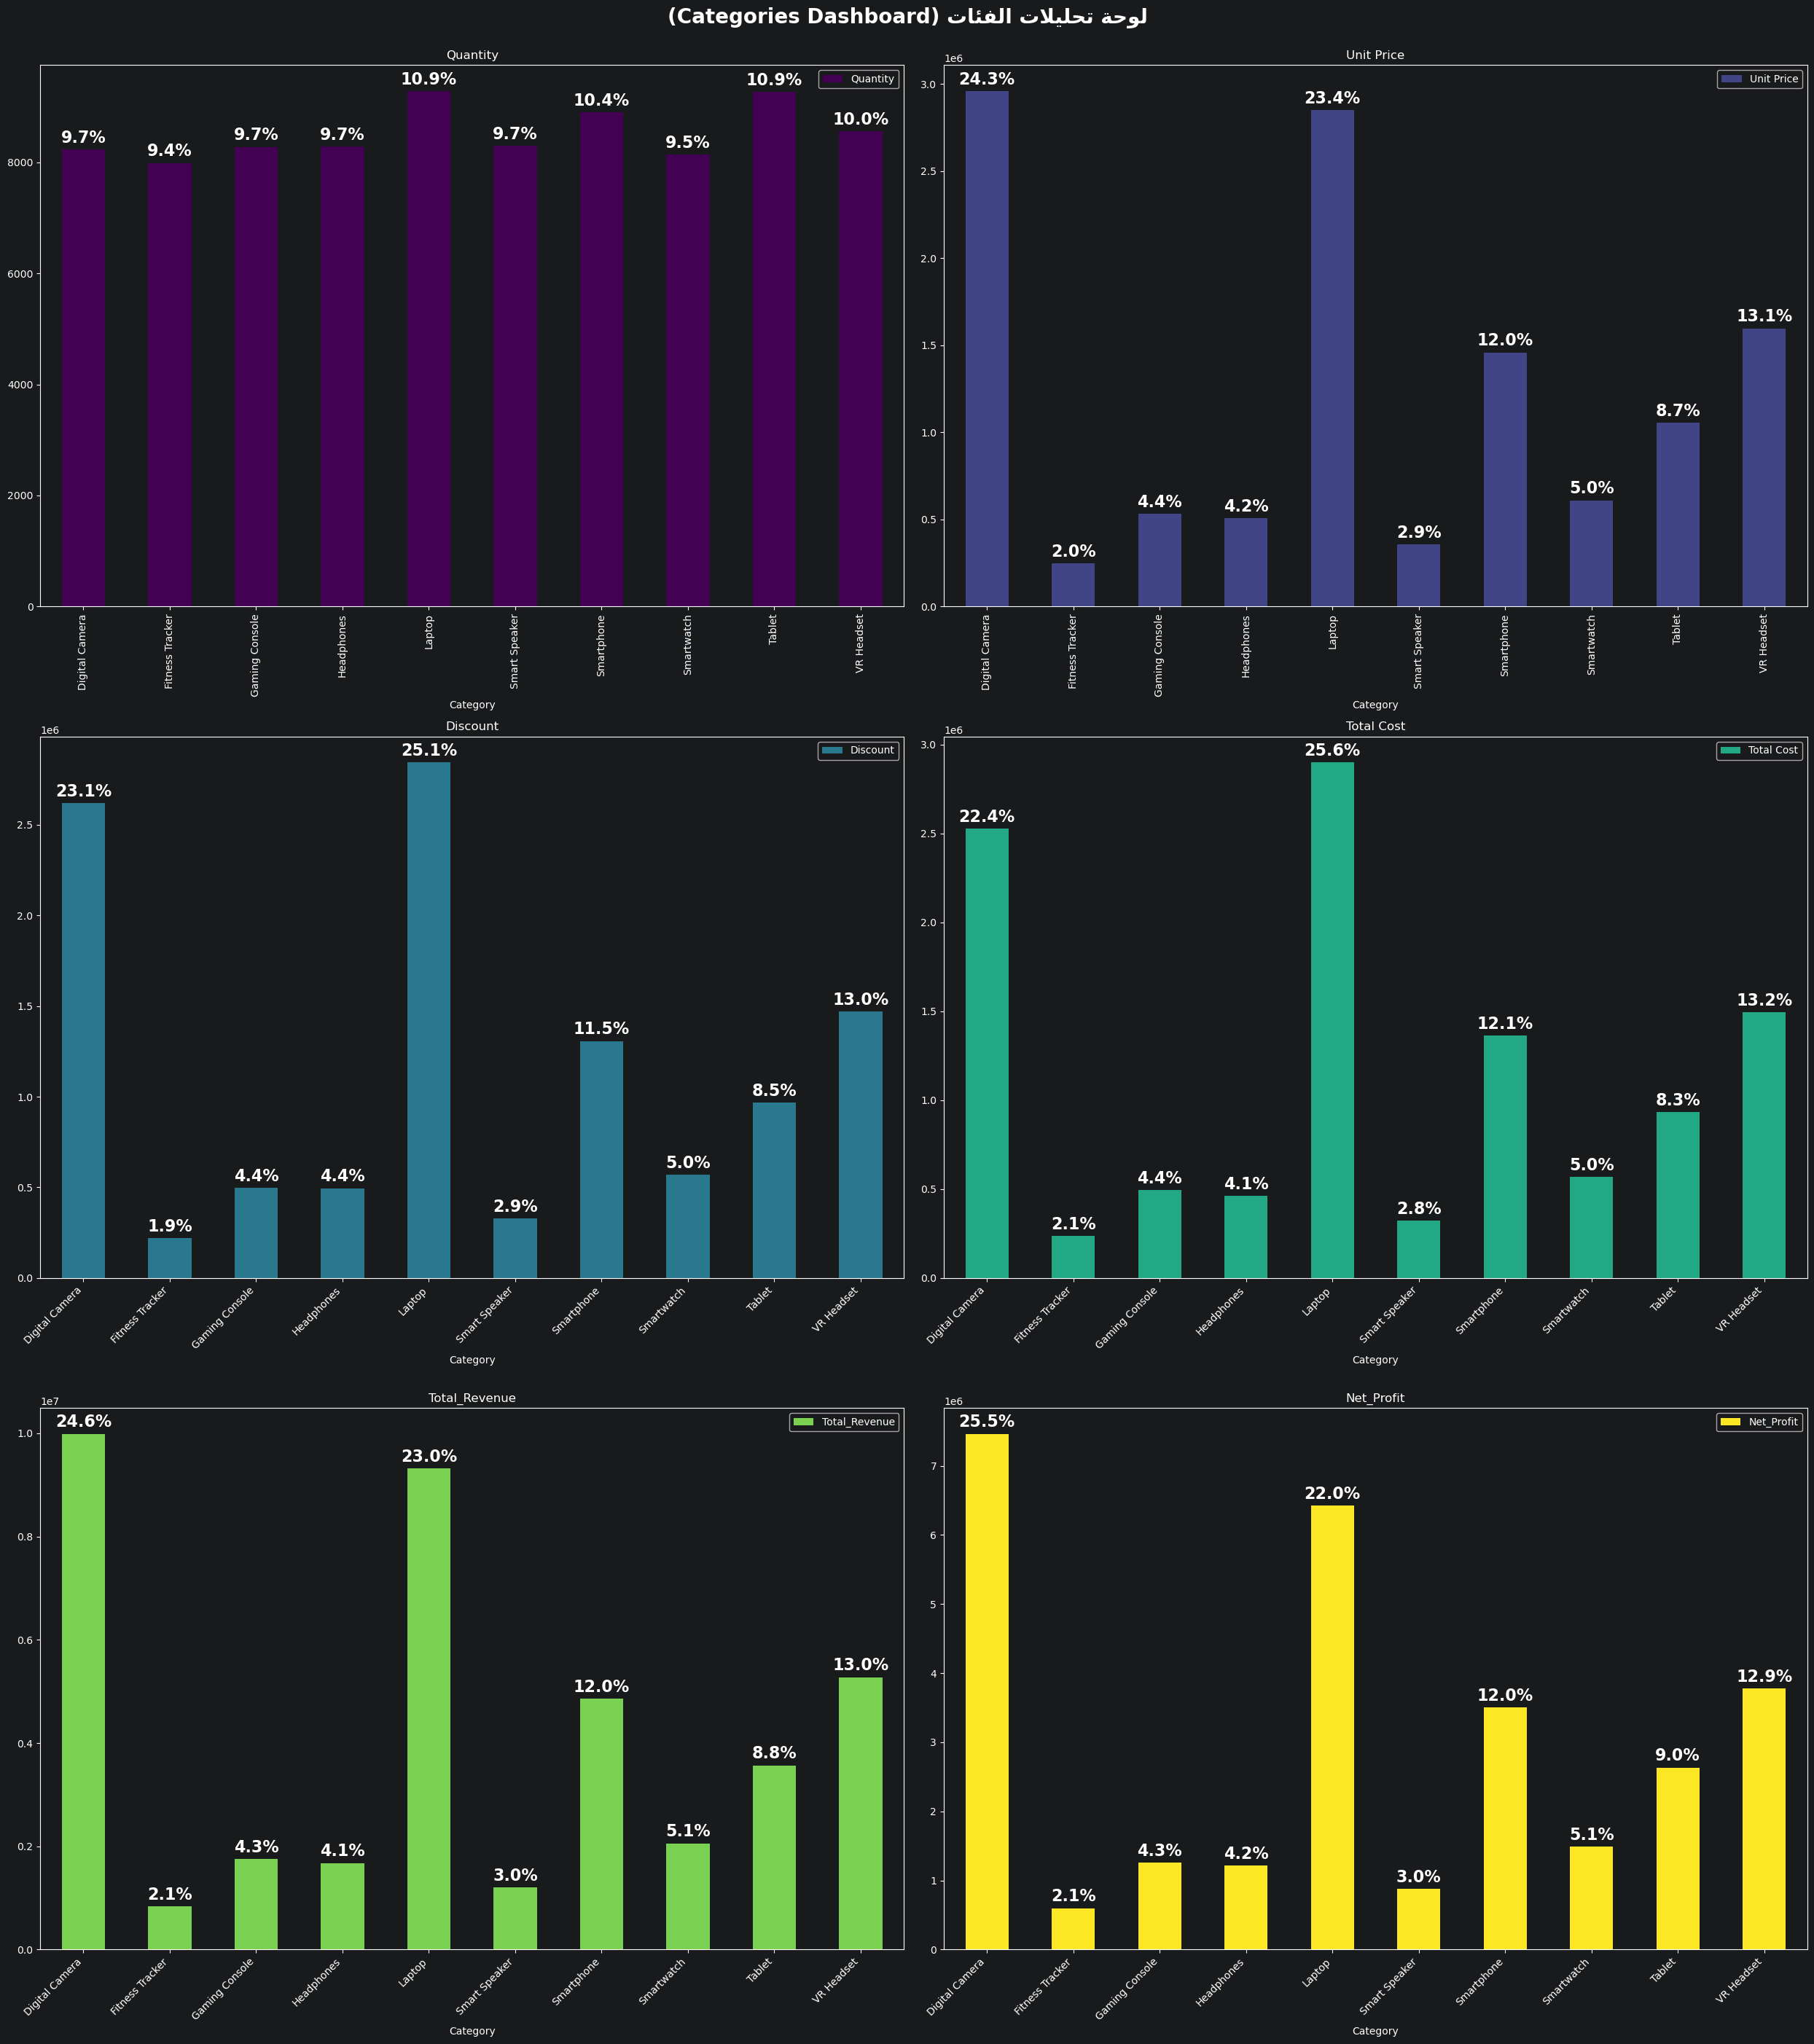

In [3]:
category = df.groupby(['Category']).agg({
    "Sub Category": 'nunique',  # سيحسب عدد الفئات الفرعية المختلفة (بدون تكرار)
    "Item": 'nunique'           # سيحسب عدد العناصر المختلفة (بدون تكرار)
}).reset_index()
sum_of_categories = df.groupby(['Category']).sum(numeric_only=True).reset_index()
sum_of_categories = sum_of_categories.loc[:,[(x not in sum_of_categories.columns[1:4]) and (x !="Status")  for x in sum_of_categories.columns]]

# 1. جعل عمود Category هو فهرس (Index) الجدول حتى تظهر أسماء الفئات على محور السينات
df_plot = sum_of_categories.set_index('Category')
# دالة لتصحيح وتشكيل النص العربي للعنوان
def fix_title(text):
    return get_display(arabic_reshaper.reshape(text))

title_corrected = fix_title('لوحة تحليلات الفئات (Categories Dashboard)')
# تجهيز البيانات بجعل Category هو الفهرس
df_plot = sum_of_categories.set_index('Category')

# 1. رسم الداشبورد وحفظ مصفوفة المحاور (Axes) لتمرير التعديلات عليها
axes = df_plot.plot(
    kind='bar',
    subplots=True,
    layout=(3, 2),
    figsize=(25, 28),
    sharex=False,
    colormap='viridis'
)

# تحويل محاور الرسم إلى مصفوفة مسطحة لسهولة التكرار عليها
axes_flat = axes.flatten()
columns = df_plot.columns
# 2. المرور على كل رسمة لإضافة القيم وتعديل التدوير
for i, ax in enumerate(axes_flat):

    # كتابة القيم فوق كل عمود تلقائياً
    # for container in ax.containers:
    #     ax.bar_label(container, fmt='%.0f', padding=3, fontsize=9, weight='bold')
    #
        col_name = columns[i]
        col_total = df_plot[col_name].sum() # إجمالي العمود بالكامل

        for container in ax.containers:
            # حساب النسبة المئوية لكل عمود فرعي بالنسبة لإجمالي العمود
            labels = [
                f'{(bar.get_height() / col_total) * 100:.1f}%' if col_total > 0 else '0%'
                for bar in container
            ]

            # عرض النسب المئوية فوق الأعمدة
            ax.bar_label(container, labels=labels, padding=3, fontsize=16, weight='bold')
    # تطبيق التدوير (45 درجة) على الرسومات الموجودة في الصف الأخير فقط (الرسمتان 4 و 5 في شبكة 3×2)

        if i >=2:
            ax.tick_params(axis='x', labelrotation=45)
            plt.setp(ax.get_xticklabels(), ha='right')

# العنوان الرئيسي وتنسيق الفراغات
plt.suptitle(title_corrected, fontsize=20, weight='bold', y=1)
plt.tight_layout()
plt.show()

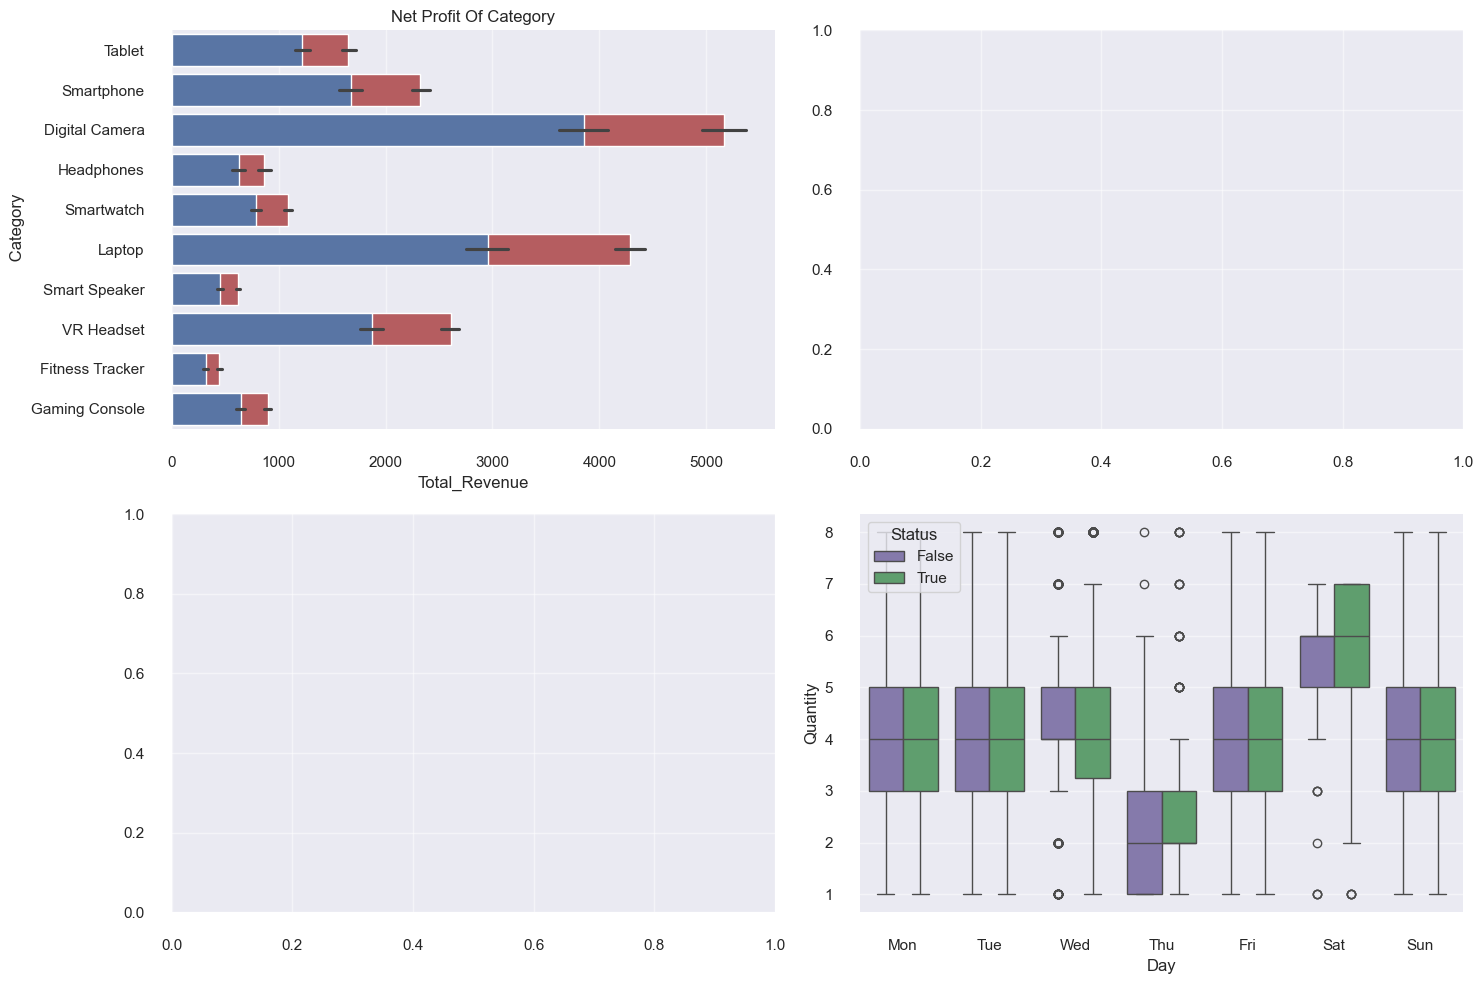

In [33]:
import seaborn as sns
f, ax = plt.subplots(2,2,figsize=(15, 10))

sns.set_theme(style="darkgrid")

sns.barplot(data=df, x="Total_Revenue", y="Category",color="r",ax=ax[0,0],)
sns.barplot(data=df, x="Net_Profit", y="Category",color="b",ax=ax[0,0])
ax[0,0].set( ylabel=" Category",title="Net Profit Of Category")


sns.boxplot(y="Quantity",
            x="Day",
            hue="Status",
            palette=["m", "g"],
            data=df)
sns.despine(offset=10, trim=True)
plt.tight_layout()

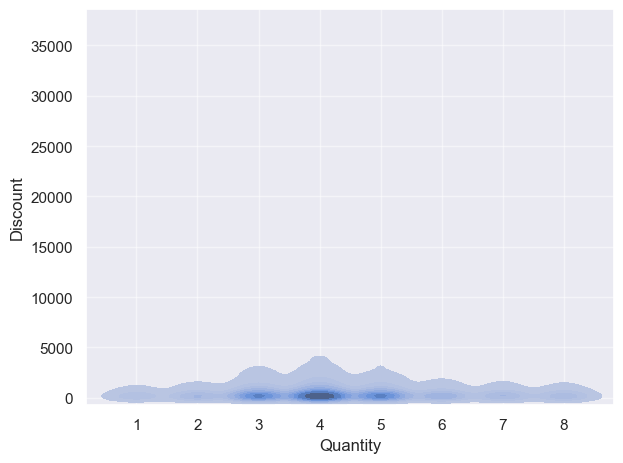

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Apply the default theme
sns.set_theme()

# Load an example dataset
tips = sns.load_dataset("tips")

# Create a 2x2 grid of subplots

# Plot KDE on the top-left subplot (ax[0, 0])
# Using 'total_bill' since 'Country' is not in the tips dataset
sns.kdeplot(data=df, x="Quantity",y="Discount", fill=True)
# Adjust spacing between subplots
plt.tight_layout()
plt.show()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


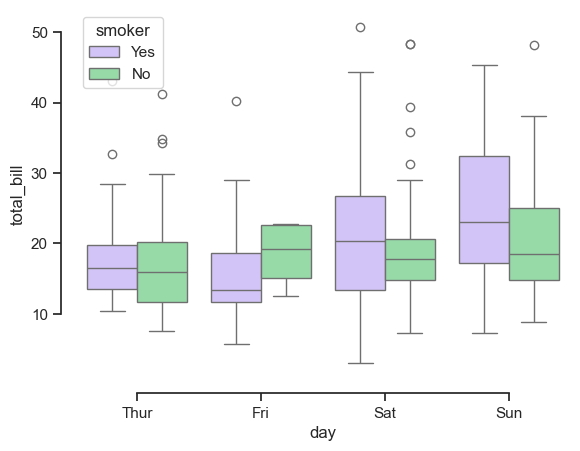

In [19]:
import seaborn as sns
sns.set_theme(style="ticks", palette="pastel")

# Load the example tips dataset
tips = sns.load_dataset("tips")

# Draw a nested boxplot to show bills by day and time
sns.boxplot(x="day", y="total_bill",
            hue="smoker", palette=["m", "g"],
            data=tips)
sns.despine(offset=10, trim=True)
tips

In [12]:
# df['Order Date'].info()


9

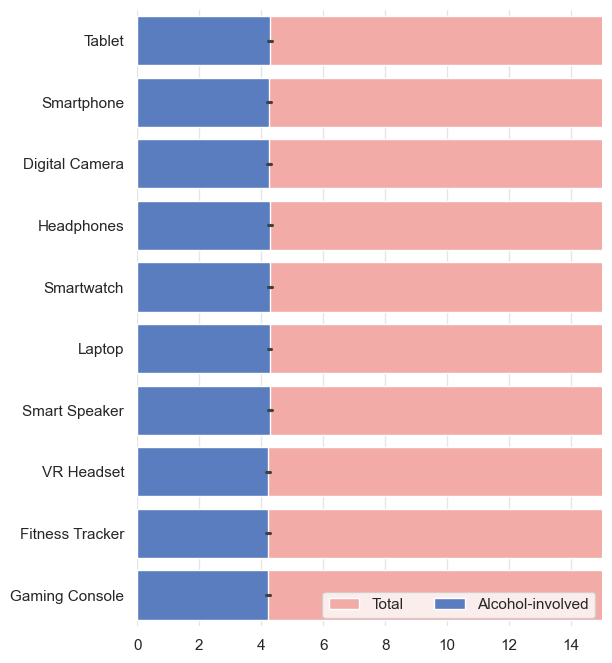

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(6, 8))

# Load the example car crash dataset
crashes = sns.load_dataset("car_crashes").sort_values("total", ascending=False)

# Plot the total crashes
sns.set_color_codes("pastel")
sns.barplot(x="Discount", y="Category", data=df,
            label="Total", color="r")

# Plot the crashes where alcohol was involved
sns.set_color_codes("muted")
sns.barplot(x="Quantity", y="Category", data=df,
            label="Alcohol-involved", color="b")

# Add a legend and informative axis label
ax.legend(ncol=2, loc="lower right", frameon=True)
ax.set(xlim=(0, 15), ylabel="",
       xlabel="")
sns.despine(left=True, bottom=True)

In [39]:
crashes

,Order ID,Order Date,Day,Country,City,Lat,Lng,Full Name,Category,Sub Category,Item,SalesPerson ID,Quantity,Unit Price,Discount,Total Cost,Status,Total_Revenue,Net_Profit,Year_Month
0,1,2023-01-01,Mon,Syria,homs,34.7326,36.7136,Lina Alrrashid,Tablet,Apple iPad,"iPad Pro 12.9""",N498,4,999,38.3616,891.9072,False,3957.6384,3065.7312,2023-01
1,2,2023-01-01,Tue,Saudi Arabia,riyadh,24.7136,46.6753,Omar Eurul,Smartphone,Samsung Galaxy,Galaxy S21 Ultra,X918,3,1199,517.9680,302.1480,True,3079.0320,2776.8840,2023-01
2,3,2023-01-01,Tue,Saudi Arabia,riyadh,24.7743,46.7386,Iman Iismaeil,Digital Camera,Panasonic Lumix,Panasonic Lumix GH5,I036,4,1299,883.3200,831.3600,True,4312.6800,3481.3200,2023-01
3,4,2023-01-01,Mon,United Arab Emirates,abu dhabi,24.4539,54.3773,Ahmad Rihan,Tablet,Samsung Galaxy Tab,Galaxy Tab A8,E804,6,199,33.3126,129.5490,True,1160.6874,1031.1384,2023-01
4,5,2023-01-01,Wed,USA,washington,38.9072,-77.0369,Sami Altawil,Headphones,Sennheiser HD,Sennheiser HD 450BT,Q149,4,129,11.2617,111.3657,True,504.7383,393.3726,2023-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,2023-09-01,Tue,Morocco,casablanca,33.5731,7.5898,Ahmad Iad,Gaming Console,Sony PlayStation,PlayStation 4 Pro,M210,4,399,150.9417,178.0338,True,1445.0583,1267.0245,2023-09
19996,19997,2023-09-01,Tue,Syria,homs,34.7326,36.7136,Ali Kiali,Smartwatch,Fossil Gen,Fossil Gen 6,Z826,3,299,398.2680,215.2800,True,498.7320,283.4520,2023-09
19997,19998,2023-09-01,Wed,USA,las vegas,36.1699,-115.1398,Husayn Salayk,Gaming Console,Sony PlayStation,PlayStation 2,K624,5,99,15.3648,56.6577,True,479.6352,422.9775,2023-09
19998,19999,2023-09-01,Mon,Saudi Arabia,jeddah,21.4858,39.1925,Fatin Bahriin,Headphones,JBL Live,JBL Live 500BT,Y368,4,99,19.9584,68.4288,True,376.0416,307.6128,2023-09
